
# Assignment: Shadow-Invariant Vision with OpenCV and Kornia

## Motivation

A shadow can create a strong image boundary even though there is no corresponding boundary in scene geometry or material.

Before beginning, watch [a Tesla on FSD 14.2.2.5 swerve for a shadow](https://x.com/EliasMartinez/status/2034946481744929113), reported by Elias Martinez in March 2026. The driver disengaged.

The central question of this assignment is:

> Can we construct an image representation that responds strongly to changes in surface reflectance but weakly to changes caused only by illumination?

You will implement a shadow-invariant representation inspired by Chapter 10 of Peter Corke's *Robotics, Vision & Control*.

[Download Chapter 10, Light and Color (PDF, 40 pages)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)

Reference notebook:

https://github.com/petercorke/RVC3-python/blob/main/notebooks/chap10.ipynb

Focus on:

- §10.1 Spectral Representation of Light
- §10.2 Color
- §10.4 Application: Color Images
- §10.4.2 Shadow Removal

You will first implement the relevant computations with NumPy and OpenCV, then port the final shadow-invariant pipeline to PyTorch/Kornia.



## Learning Objectives

By the end of this assignment, you should be able to:

1. Explain why shadows alter image measurements without altering surface material.
2. Relate illumination spectra to measured color.
3. Compare RGB, HSV, and Lab for illuminated and shadowed regions.
4. Construct a log-chromaticity representation.
5. Compute a one-dimensional shadow-invariant image.
6. Quantitatively evaluate shadow suppression.
7. Port the final computation to a PyTorch/Kornia tensor pipeline.



# 1. Development Environment

Use the course development environment:

https://github.com/pantelis/eng-ai-agents

Open the repository in VS Code as a Dev Container.

Inside the container run:

```bash
make start
make install-notebooks
source .venv/bin/activate
```

`make start` alone installs only the base dependencies. `make install-notebooks` adds OpenCV, PyTorch and Kornia, which the sections below use.

GPU acceleration is not required for full credit.


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia
import time

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Kornia:", kornia.__version__)
print("CUDA available:", torch.cuda.is_available())


/workspaces/eng-ai-agents/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


OpenCV: 5.0.0
NumPy: 2.4.6
PyTorch: 2.14.0+cu126
Kornia: 0.8.3
CUDA available: True



# 2. Why Does a Shadow Change an Image?

A simplified image-formation model is

$$
I_k =
\int E(\lambda)R(\lambda)Q_k(\lambda)\,d\lambda,
$$

where

- $E(\lambda)$ is illumination,
- $R(\lambda)$ is surface reflectance,
- $Q_k(\lambda)$ is the spectral response of camera channel $k$.

The key observation is:

$$
\text{measured pixel value} \neq \text{surface reflectance alone}.
$$

Measured RGB depends on both the material and the illumination.

In a cast shadow, the material reflectance is approximately unchanged, but the illumination reaching the surface changes.



## 2.1 Blackbody Illumination

Implement Planck's law:

$$
B(\lambda,T)
=
\frac{2hc^2}{\lambda^5}
\frac{1}
{\exp\left(\frac{hc}{\lambda k_BT}\right)-1}.
$$

Plot normalized spectra for:

$$
T_1 = 2600\text{ K},
\qquad
T_2 = 5778\text{ K}.
$$

Answer briefly:

1. Why can the same material produce different RGB values under these two illuminants? 

2. In a cast shadow, what changes: reflectance or illumination?

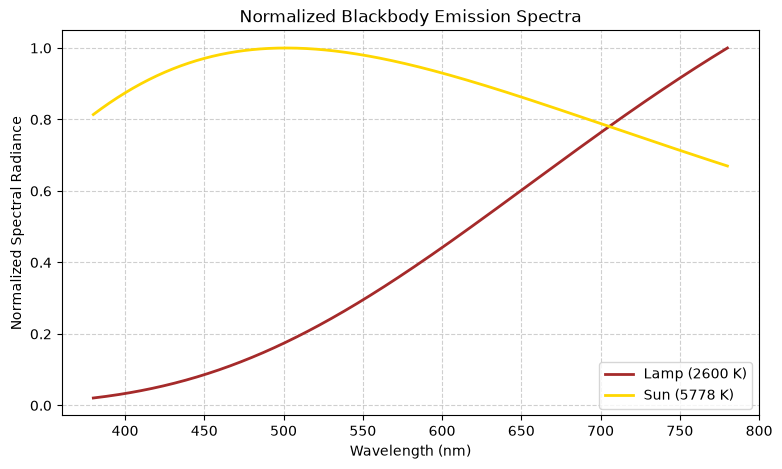

In [2]:

def blackbody(wavelength_m, temperature_k):
    # TODO: implement Planck's blackbody radiation equation.

    h = 6.62607015e-34    # Planck constant (J * s)
    c = 2.99792458e8      # Speed of light (m/s)
    k_B = 1.380649e-23    # Boltzmann constant (J/K)
    
    # Exponent: (h * c) / (lambda * k_B * T)
    exponent = (h * c) / (wavelength_m * k_B * temperature_k)
    intensity = (2.0 * h * (c**2)) / ((wavelength_m**5) * (np.exp(exponent) - 1.0))
    return intensity


wavelength_nm = np.linspace(380, 780, 400)
wavelength_m = wavelength_nm * 1e-9


# TODO:
lamp = blackbody(wavelength_m, 2600)
sun = blackbody(wavelength_m, 5778)

# Normalize each curve and plot both.
lamp_norm = lamp / np.max(lamp)
sun_norm = sun / np.max(sun)



plt.figure(figsize=(9, 5))
plt.plot(wavelength_nm, lamp_norm, label="Lamp (2600 K)", color="brown", linewidth=2)
plt.plot(wavelength_nm, sun_norm, label="Sun (5778 K)", color="gold", linewidth=2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Spectral Radiance")
plt.title("Normalized Blackbody Emission Spectra")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


### Short Answer

Write your response here.

- Same material, different illuminants: As shown in the formula for a simplified image-formation model, Illumination and Surface Reflection are primary componenets. A change in the light source shifts the incoming spectral power distribution. As seen in the graph, these have quite different curvves of radiance compared to each other, with the Sun-like light source providing a gererally equal distribution of radiance across the spectrum, while a Lamp-like source is more red-leaning and provides more radiance in that area. This results in the different RGB values even when the other elements like Surface Reflection is the same. 

- What changes in a cast shadow: Illumination changes. The surface and it's reflective properties doen't change just because a tree decided to grow some leaves above it (in general lol). Although the light can be blocked by something like leaves, the surface still maintains it's reflective properties, it just recieves less illumination, if any. 



# 3. Observe a Shadow in Different Color Spaces

Use Corke's `parks.png` image or another supplied outdoor image containing a strong cast shadow.

Load the image with OpenCV and select two small regions of the same physical surface:

- one directly illuminated,
- one inside the shadow.

You will compare the regions in RGB, HSV, and Lab.


Image shape (H, W, C): (2448, 3264, 3)


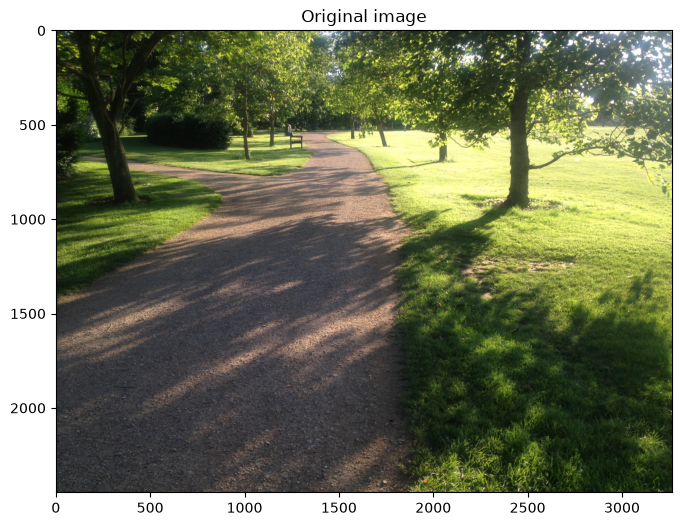

In [3]:

import os
import urllib.request

# parks.png is the outdoor scene Corke uses in chapter 10. It ships with the
# Machine Vision Toolbox data package (Peter Corke, MIT license).

# OPTIONAL: point this at your own image if you prefer
IMAGE_URL = (
    "https://raw.githubusercontent.com/petercorke/machinevision-toolbox-python/"
    "main/packages/mvtb-data/mvtbdata/images/parks.png"
)
IMAGE_PATH = "parks.png"  


if not os.path.exists(IMAGE_PATH):
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(
        f"Could not load {IMAGE_PATH}. Check the path, or download the image "
        f"yourself from {IMAGE_URL}."
    )

print("Image shape (H, W, C):", image_bgr.shape)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Original image")
plt.show()



## 3.1 Define Illuminated and Shadowed Regions

Choose two rectangular regions containing the same material.

Store them as:

```python
(x1, y1, x2, y2)
```

where `(x1, y1)` is the upper-left corner and `(x2, y2)` is the lower-right corner.


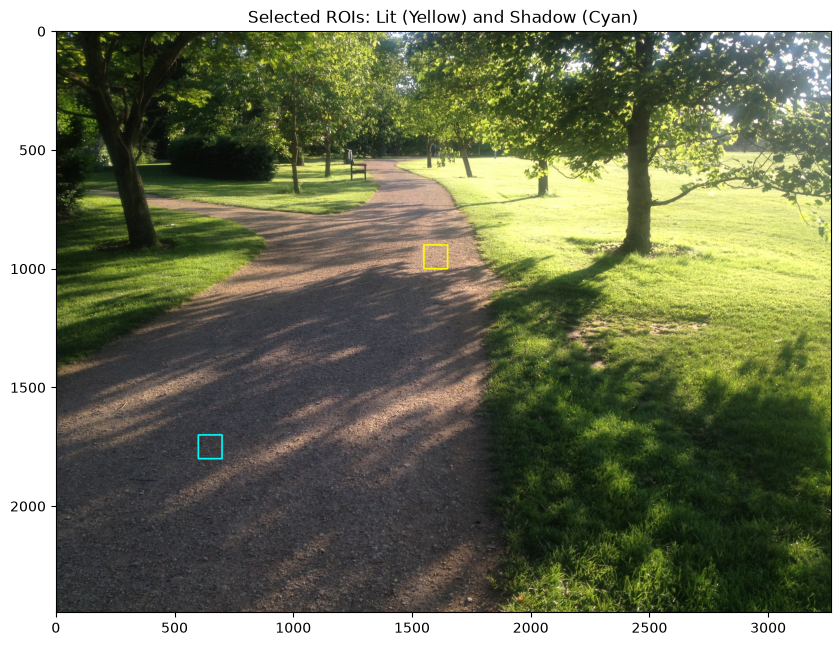

In [4]:

# TODO: replace with coordinates appropriate for your image.
lit_roi = (1550, 900, 1650, 1000)
shadow_roi = (600, 1700, 700, 1800)

def crop_roi(image, roi):
    x1, y1, x2, y2 = roi
    return image[y1:y2, x1:x2]

def mean_color(image, roi):
    patch = crop_roi(image, roi)
    return patch.reshape(-1, patch.shape[-1]).mean(axis=0)


# TODO: visualize the chosen rectangles on the image.
# Create a copy so we don't alter the original image
vis_image = image_rgb.copy()

# Draw Lit ROI (Yellow) and Shadow ROI (Cyan) with thickness=6 for high-res
cv2.rectangle(vis_image, (lit_roi[0], lit_roi[1]), (lit_roi[2], lit_roi[3]), (255, 255, 0), 6)
cv2.rectangle(vis_image, (shadow_roi[0], shadow_roi[1]), (shadow_roi[2], shadow_roi[3]), (0, 255, 255), 6)


plt.figure(figsize=(10, 8))
plt.imshow(vis_image)
plt.title("Selected ROIs: Lit (Yellow) and Shadow (Cyan)")
plt.show()


In [5]:

hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

rgb_lit = mean_color(image_rgb, lit_roi)
rgb_shadow = mean_color(image_rgb, shadow_roi)

hsv_lit = mean_color(hsv, lit_roi)
hsv_shadow = mean_color(hsv, shadow_roi)

lab_lit = mean_color(lab, lit_roi)
lab_shadow = mean_color(lab, shadow_roi)

print("RGB lit:    ", rgb_lit)
print("RGB shadow: ", rgb_shadow)
print("HSV lit:    ", hsv_lit)
print("HSV shadow: ", hsv_shadow)
print("Lab lit:    ", lab_lit)
print("Lab shadow: ", lab_shadow)

RGB lit:     [200.1682 163.358  136.6998]
RGB shadow:  [59.0679 58.5384 63.3773]
HSV lit:     [ 12.5983  82.1071 200.1682]
HSV shadow:  [122.605   20.9123  63.3841]
Lab lit:     [177.7378 137.742  147.0017]
Lab shadow:  [ 63.3539 129.4201 125.0744]



### Questions

1. Which components change most strongly across the shadow?
- The intensity components change most. In RGB, all three color channels drop by more than 50%. In HSV, Value (V) drops sharply, and in Lab, Lightness (L) shows by far the largest decrease.

2. Does converting to HSV or Lab completely remove the shadow?
- No. As shown earlier, illuminants can produce varying radiance across the spectrums. This influences Hue and Saturation in HSV, and the "ab" in Lab effectively measures hue.  

3. Why is separating intensity from chromatic information useful?
- As we found earlier, illumination is a changing factor in cases of shadows. By seperating illumination from the color factor of the color representation, we can have a more reliable metric for our algorithms to use. 



# 4. Implement the Shadow-Invariant Image

This is the main part of the assignment.

Do not use Corke's `shadow_invariant()` function.

You will implement:

1. sRGB linearization
2. log chromaticity
3. 2-D projection
4. a 1-D invariant image



## 4.1 Convert sRGB to Linear RGB

Convert the image to floating-point RGB in $[0,1]$.

Implement the inverse sRGB transfer function:

$$
C_{\text{linear}}
=
\begin{cases}
C_{\text{sRGB}}/12.92,
&
C_{\text{sRGB}}\leq0.04045
\\[4pt]
\left(
\frac{C_{\text{sRGB}}+0.055}{1.055}
\right)^{2.4},
&
\text{otherwise}.
\end{cases}
$$


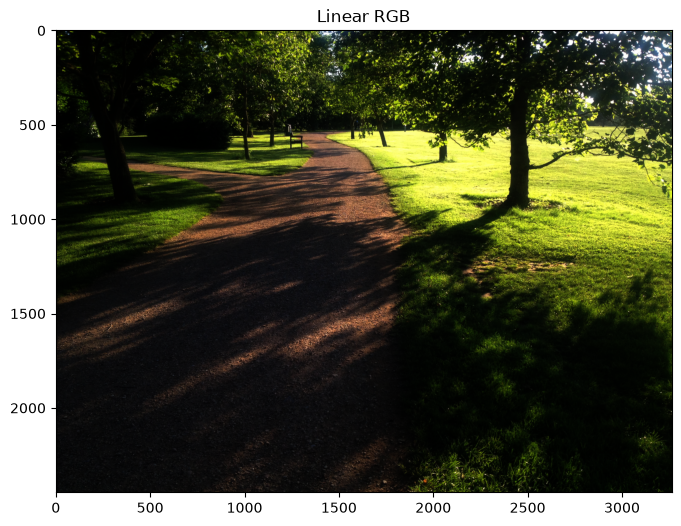

In [6]:

def srgb_to_linear(rgb):
    # rgb must be float32/float64 in [0, 1]
    # TODO: implement the inverse sRGB transfer function.
    
    return np.where(
        rgb <= 0.04045,
        rgb / 12.92,
        np.power((rgb + 0.055) / 1.055, 2.4)
    )


rgb = image_rgb.astype(np.float32) / 255.0
linear_rgb = srgb_to_linear(rgb)



# TODO: display linear_rgb after clipping to [0,1].

plt.figure(figsize=(10, 6))
plt.imshow(np.clip(linear_rgb, 0.0, 1.0))
plt.title("Linear RGB")
plt.show()


## 4.2 Log Chromaticity

For each pixel compute the geometric mean

$$
M=(RGB)^{1/3}.
$$

Then define

$$
\rho_R=\log\frac{R}{M},
\qquad
\rho_G=\log\frac{G}{M},
\qquad
\rho_B=\log\frac{B}{M}.
$$

Use a small $\epsilon$ for numerical stability.

Verify numerically that

$$
\rho_R+\rho_G+\rho_B\approx0.
$$


In [7]:

def log_chromaticity(linear_rgb, eps=1e-6):
    # TODO:
    # 1. clamp values with eps
    # 2. compute geometric mean M
    # 3. compute rho_R, rho_G, rho_B
    # 4. stack into an H x W x 3 array

    clamped = np.clip(linear_rgb, eps, None)
    log_rgb = np.log(clamped)
    log_M = np.mean(log_rgb, axis=-1, keepdims=True)
    rho = log_rgb - log_M
    return rho.astype(np.float32)


rho = log_chromaticity(linear_rgb)

# TODO: verify rho[...,0] + rho[...,1] + rho[...,2] is approximately zero.

rho_sum = np.sum(rho, axis=-1)
max_dev = np.max(np.abs(rho_sum))
print("Max absolute deviation from zero for sum(rho):", max_dev)
assert np.allclose(rho_sum, 0.0, atol=1e-5), "rho does not sum to 0!"

Max absolute deviation from zero for sum(rho): 2.3841858e-06



## 4.3 Project to a Two-Dimensional Chromaticity Plane

Use the orthonormal basis

$$
u_1=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1\\
0
\end{bmatrix},
\qquad
u_2=
\frac{1}{\sqrt{6}}
\begin{bmatrix}
1\\
1\\
-2
\end{bmatrix}.
$$

Compute

$$
\chi_1=u_1^T\rho,
\qquad
\chi_2=u_2^T\rho.
$$


In [8]:

u1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
u2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)

# TODO: compute chi1 and chi2 for all pixels.
chi1 = np.dot(rho, u1)
chi2 = np.dot(rho, u2)



## 4.4 Plot Illuminated and Shadowed Pixels in Log-Chromaticity Space

Plot pixels from the two selected ROIs in $(\chi_1,\chi_2)$ coordinates.

Use different markers or colors for the illuminated and shadowed regions.

Do the two groups appear displaced primarily along a common direction?


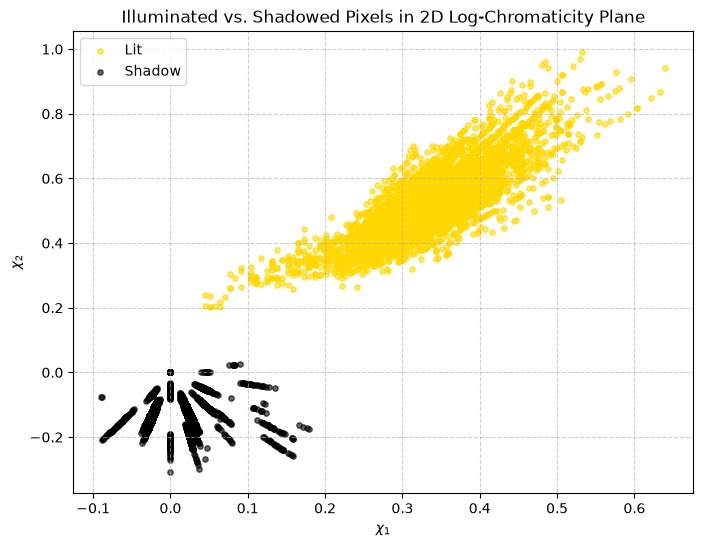

In [9]:

def roi_values(image_2d, roi):
    x1, y1, x2, y2 = roi
    return image_2d[y1:y2, x1:x2].ravel()


# TODO:
lit_x = roi_values(chi1, lit_roi)
lit_y = roi_values(chi2, lit_roi)
shadow_x = roi_values(chi1, shadow_roi)
shadow_y = roi_values(chi2, shadow_roi)


# plt.scatter(...)
plt.figure(figsize=(8, 6))
plt.scatter(lit_x, lit_y, color="gold", label="Lit", alpha=0.6, s=15)
plt.scatter(shadow_x, shadow_y, color="black", label="Shadow", alpha=0.6, s=15)
plt.xlabel(r"$\chi_1$")
plt.ylabel(r"$\chi_2$")
plt.title(r"Illuminated vs. Shadowed Pixels in 2D Log-Chromaticity Plane")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## 4.5 Shadow-Invariant Projection

Reproduce Corke's fixed-angle example using

$$
\theta=0.7\text{ rad}.
$$

Compute

$$
I_{\text{inv}}
=
\chi_1\cos\theta
+
\chi_2\sin\theta.
$$

Normalize only for visualization.


In [10]:

theta = 0.7 # Radians

# TODO:
invariant = chi1 * np.cos(theta) + chi2 * np.sin(theta)

# Normalize for display only:
invariant_display = cv2.normalize(
    invariant, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)



Display side-by-side:

1. original RGB image,
2. ordinary grayscale image,
3. shadow-invariant image.

Then answer:

1. Which shadow boundaries became weaker?
- The tree's shadows on the pavement get noticabely more faded into the walking surface in the shadow-invariant image. Along with that, the boundary between the grass and the right side of the surface loses a lot of the detail from the shadow of the grass.


2. Which physical or material boundaries remained?
- The bodies and leaves of the trees, and the boundary between the grass and surface on the left are still identifiable. 

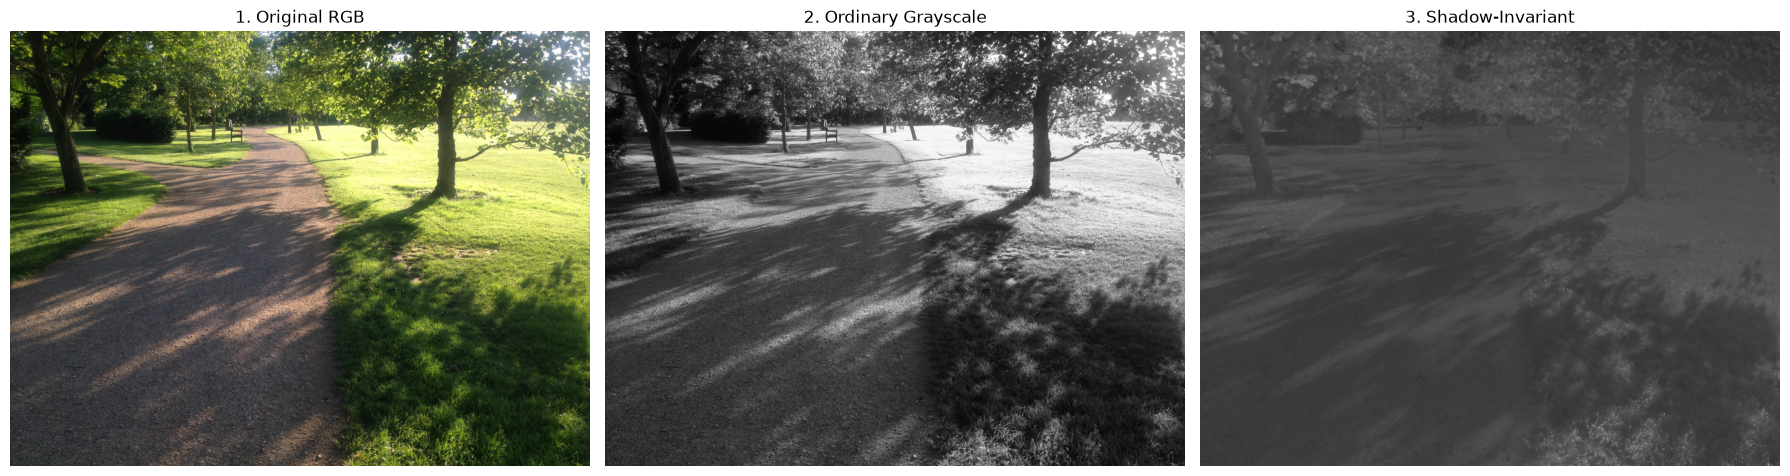

In [11]:

gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# TODO: create a 1x3 figure showing:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# original RGB
axes[0].imshow(image_rgb)
axes[0].set_title("1. Original RGB")
axes[0].axis("off")

# grayscale
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("2. Ordinary Grayscale")
axes[1].axis("off")

# invariant_display
axes[2].imshow(invariant_display, cmap="gray")
axes[2].set_title(r"3. Shadow-Invariant")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# 5. Quantitative Evaluation

Use the same illuminated and shadowed ROIs.

For grayscale compute

$$
\Delta_{\text{gray}}
=
|\mu_{\text{lit}}-\mu_{\text{shadow}}|.
$$

For the invariant image compute

$$
\Delta_{\text{inv}}
=
|\mu_{\text{lit}}^{\text{inv}}
-
\mu_{\text{shadow}}^{\text{inv}}|.
$$

A successful representation should approximately satisfy

$$
\Delta_{\text{inv}} < \Delta_{\text{gray}}.
$$


In [12]:

def mean_scalar(image_2d, roi):
    return roi_values(image_2d, roi).mean()

# TODO:

# delta_gray = ...
mu_lit_gray = mean_scalar(gray.astype(np.float32), lit_roi)
mu_shadow_gray = mean_scalar(gray.astype(np.float32), shadow_roi)
delta_gray = np.abs(mu_lit_gray - mu_shadow_gray)

# delta_inv = ...
mu_lit_inv = mean_scalar(invariant_display.astype(np.float32), lit_roi)
mu_shadow_inv = mean_scalar(invariant_display.astype(np.float32), shadow_roi)
delta_inv = np.abs(mu_lit_inv - mu_shadow_inv)

# print(...)
print(f"Grayscale difference  (Delta_gray): {delta_gray:.2f}")
print(f"Invariant difference  (Delta_inv):  {delta_inv:.2f}")
print(f"Shadow suppression condition Delta_inv < Delta_gray satisfied: {delta_inv < delta_gray}")


Grayscale difference  (Delta_gray): 112.08
Invariant difference  (Delta_inv):  18.59
Shadow suppression condition Delta_inv < Delta_gray satisfied: True



## 5.1 Compare Edges

Use OpenCV Canny on:

1. the ordinary grayscale image,
2. the normalized shadow-invariant image.

Look for one shadow edge and one real material/object edge.

The desired behavior is:

- weaker response at the shadow boundary,
- preservation of real scene boundaries.


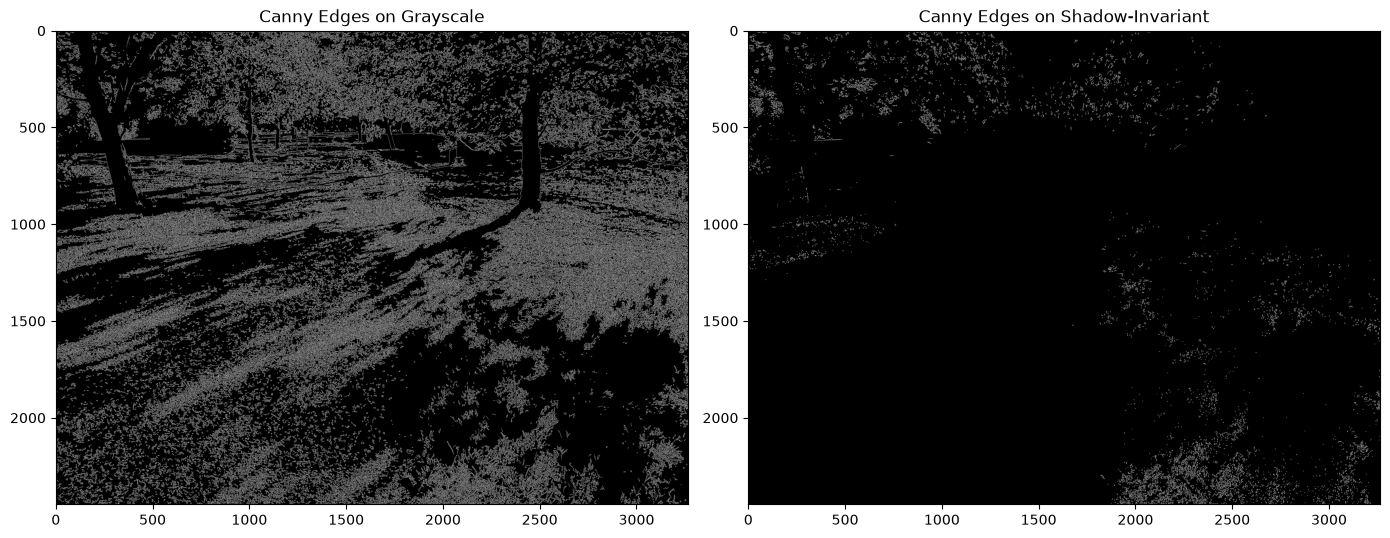

In [13]:

# TODO: tune thresholds if needed.
edges_gray = cv2.Canny(gray, 50, 150)


# TODO:
edges_inv = cv2.Canny(invariant_display, 50, 150)


# TODO: display both edge maps.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(edges_gray, cmap="gray")
axes[0].set_title("Canny Edges on Grayscale")


axes[1].imshow(edges_inv, cmap="gray")
axes[1].set_title("Canny Edges on Shadow-Invariant")


plt.tight_layout()
plt.show()


# 6. Port the Final Pipeline to PyTorch and Kornia

The goal of this section is to express the same classical computer-vision pipeline as tensor operations.

This allows:

- batching,
- GPU execution,
- automatic differentiation.

Kornia provides differentiable computer-vision operators that integrate directly with PyTorch computation graphs.


In [14]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rgb_t = (
    torch.from_numpy(image_rgb)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    .div(255.0)
    .to(device)
)

print("Tensor shape:", rgb_t.shape)
print("Device:", rgb_t.device)


Tensor shape: torch.Size([1, 3, 2448, 3264])
Device: cuda:0



## 6.1 Linear RGB with Kornia

Use:

```python
kornia.color.rgb_to_linear_rgb(...)
```

Then reproduce the same log-chromaticity and projection equations using PyTorch tensor operations.


In [15]:

linear_t = kornia.color.rgb_to_linear_rgb(rgb_t)

def shadow_invariant_torch(linear_rgb_t, theta=0.7, eps=1e-6):
    # Expected input shape: B x 3 x H x W
    #
    # TODO:
    

    # 1. clamp channels with eps
    clamped = torch.clamp(linear_rgb_t, min=eps)
    
    # 2. compute geometric mean
    log_rgb = torch.log(clamped)
    log_M = torch.mean(log_rgb, dim=1, keepdim=True)
    rho = log_rgb - log_M  # Shape: (B, 3, H, W)
    
    # 3. compute log chromaticities
    u1 = torch.tensor([1.0, -1.0, 0.0], device=linear_rgb_t.device, dtype=linear_rgb_t.dtype) / np.sqrt(2.0)
    u2 = torch.tensor([1.0, 1.0, -2.0], device=linear_rgb_t.device, dtype=linear_rgb_t.dtype) / np.sqrt(6.0)
    
    # 4. project using u1 and u2
    u1 = u1.view(1, 3, 1, 1)
    u2 = u2.view(1, 3, 1, 1)
    
    # 4. Project using u1 and u2
    chi1 = torch.sum(rho * u1, dim=1)  # Shape: (B, H, W)
    chi2 = torch.sum(rho * u2, dim=1)  # Shape: (B, H, W)
    
    # 5. compute invariant = chi1*cos(theta) + chi2*sin(theta)
    theta_t = torch.tensor(theta, device=linear_rgb_t.device, dtype=linear_rgb_t.dtype)

    # Return shape: B x H x W
    invariant = chi1 * torch.cos(theta_t) + chi2 * torch.sin(theta_t)

    return invariant



invariant_t = shadow_invariant_torch(linear_t, theta=0.7)



## 6.2 Compare NumPy/OpenCV and PyTorch/Kornia Results

Compute

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_i
|I_i^{\mathrm{NumPy}}
-
I_i^{\mathrm{PyTorch}}|.
$$

The two implementations should be numerically very similar.


In [16]:

# TODO:
invariant_t_np = invariant_t.squeeze(0).detach().cpu().numpy()
mae = np.mean(np.abs(invariant - invariant_t_np))
print("MAE:", mae)

MAE: 1.136940188203374e-07



## 6.3 Optional GPU Batch Experiment

If CUDA is available, process a batch of 32 identical images.

Report:

- execution device,
- batch shape,
- elapsed time.

No GPU speedup is required for full credit.


In [17]:
if torch.cuda.is_available():
    batch = rgb_t.repeat(4, 1, 1, 1)
    batch_linear = kornia.color.rgb_to_linear_rgb(batch)

    torch.cuda.synchronize()
    t0 = time.perf_counter()

    # TODO:
    batch_inv = shadow_invariant_torch(batch_linear, theta=0.7)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    print("Batch shape:", batch.shape)
    print("Elapsed:", elapsed)
else:
    print("CUDA not available; GPU timing is optional.")



Batch shape: torch.Size([4, 3, 2448, 3264])
Elapsed: 0.0691326028900221



# 7. Discussion

Return to the autonomous-driving example at the beginning.

Answer in approximately one paragraph:

1. Why does the shadow generate strong image structure even though there is no new physical object?
- Casted shadows produce strong differences in radiance when direct light is blocked by something as opaque as a leaf. Image sensors (generally) measure total radiance (going back to the earliest formula). This causes non-regular dip in light presents itself in a similar manner as potential physical objects. Since the pattern of coverage follows the projection of the covering object, certain things like telephone poles can present a straight line, resulting in a shadow that can mimic a road line. 


2. What quantity does the invariant projection attempt to suppress?
- It tries to remove changes caused by lighting. Specifically, it aims to remove the overall drop in brightness, and some slight color temperate shifts (since shadows look slightly cooler/bluer because they are exposed to an open sky versus direct sunlight). By projecting color values perpendicular to the line where lighting changes happen, the illumination differences cancel out and "leaves" (pun intended) the true color of the material behind.


3. Why can preserving reflectance-related edges while suppressing illumination edges help perception?
- In the case of self-driving, preserving reflection-related edges and surpressing illumination edges can help with perception by aligning it closer with real physical elements. Modern roadways are designed to have very contrasting elements, such as yellow and white lines on black or grey roads with green grass and blue skies. If a car's vision system can ignore shadow edges while identifying painted lines and road boundaries, it won't hallucinate "phantom obstacles" on the road, preventing incorrect decisions.  


4. Why would this classical method still be insufficient by itself for autonomous driving?
- As mentioned earlier, this methodology brings the focus to colors, not light intensity. And in a perfect world, this would be much more usable. However, since the most popular light source, the sun, can appear and disappear throughout the day, as well as naturally inconsistent road boundaries (like some backroads), the reliance on just color as a primary decision indicator is not strong enough to safely control a speeding metal box in public. Along with that, I personally feel like the method didn't even do that good of a job removing the boundaries between the shadow and the road, and it was actually removing the edges of the surface. This could be human error but I'll find out from the score I guess :) 

Consider geometry, depth, semantics, temporal reasoning, learned representations, and sensor fusion.



# Deliverables

Your notebook must execute from beginning to end, and you must submit it with all outputs saved.

Required outputs:

- two blackbody curves,
- RGB/HSV/Lab comparison,
- log-chromaticity scatter plot,
- shadow-invariant image,
- quantitative shadow comparison,
- OpenCV edge comparison,
- PyTorch/Kornia implementation,
- short final discussion.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.

The per-component points are on the assignment page.



# References

1. Peter Corke, *Robotics, Vision & Control: Fundamental Algorithms in Python*, 3rd ed., Springer, Chapter 10. [Download the chapter (PDF)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)
2. G. D. Finlayson, S. D. Hordley, and M. S. Drew, "Removing Shadows from Images," ECCV, 2002.
3. G. D. Finlayson, M. S. Drew, and C. Lu, "Intrinsic Images by Entropy Minimization," ECCV, 2004.
4. G. D. Finlayson, S. D. Hordley, C. Lu, and M. S. Drew, "On the Removal of Shadows from Images," IEEE TPAMI, 2006.
5. Kornia documentation: https://kornia.readthedocs.io/
6. OpenCV documentation: https://docs.opencv.org/
